# 52 —  Stardist receptive field

This notebook tests training stardist networks, with different receptive fields on circles. 

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile
from matplotlib.patches import Rectangle
from skimage.measure import regionprops
from tnia.plotting.plt_helper import imshow_multi2d, mask_outline_overlay

import circles
from skop.runner import Runner
from skop.ops.segment.stardist2d import stardist2d_custom
from skop.ops.train import extent, receptive_field_stardist2d, train_stardist2d

runner = Runner()

RADII = [3, 5, 15, 30, 60, 70]
test_img, test_lbl = circles.calibration(RADII)

DIAMETERS = [2 * r for r in RADII]
print('test image', test_img.shape, 'diameters', DIAMETERS)

test image (256, 534) diameters [6, 10, 30, 60, 120, 140]


In [2]:
# scikit-ops is in heavy development, so for now it is worth "ensuring" the
# environment each time -- check it is up to date, rebuild it if not.
runner.ensure_environment('stardist-tf')

stardist-tf: up to date


<appose.builder.BaseBuilder._create_env.<locals>.BuiltEnvironment at 0x1ce4e7d2ae0>

## Measure the receptive field

Send one bright pixel through the network. How far the response spreads is
what the network can see.  Performance of the network will be constrained by how many pixels it can see.  

In [3]:
# Barely any depth, so a very small field on purpose.
SMALL_GRID, SMALL_DEPTH = 1, 1
BIG_GRID, BIG_DEPTH = 1, 4

small_net_field = min(extent(runner.run(
    receptive_field_stardist2d,
    grid_size_xy=SMALL_GRID,
    unet_n_depth=SMALL_DEPTH,
    n_channel_in=1,
    img_size=512,
)))
print(f'grid={SMALL_GRID} depth={SMALL_DEPTH} -> {small_net_field} px')

grid=1 depth=1 -> 20 px


In [4]:
# Four levels deep, so the field covers the biggest circle.
big_net_field = min(extent(runner.run(
    receptive_field_stardist2d,
    grid_size_xy=BIG_GRID,
    unet_n_depth=BIG_DEPTH,
    n_channel_in=1,
    img_size=512,
)))
print(f'grid={BIG_GRID} depth={BIG_DEPTH} -> {big_net_field} px')

grid=1 depth=4 -> 180 px


In [5]:
small = f'small net (rf={small_net_field})'
big = f'big net (rf={big_net_field})'
print(f'{"diameter":>17} {small:>19} {big:>21}')
#print(f'{"diameter":>10} {"small net (rf={small_net_field})":>12} {"big net (rf={big_net_field})":>10}')
for d in DIAMETERS:
    print(f'{d:>17} {"sees it" if small_net_field >= d else "too small":>19} '
          f'{"sees it" if big_net_field >= d else "too small":>21}')

         diameter   small net (rf=20)      big net (rf=180)
                6             sees it               sees it
               10             sees it               sees it
               30           too small               sees it
               60           too small               sees it
              120           too small               sees it
              140           too small               sees it


## See it on the circles

The red square is what the network sees. Both squares are drawn on the
biggest circle.

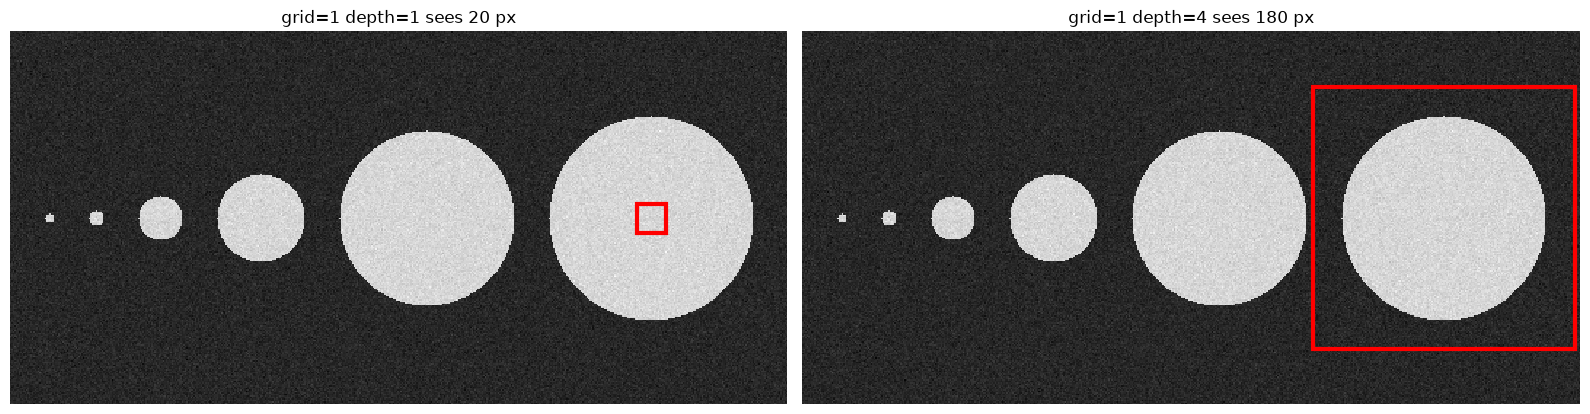

In [6]:
cy, cx = test_img.shape[0] // 2, test_img.shape[1] - 24 - RADII[-1]

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for a, field, name in [(ax[0], small_net_field, f'grid={SMALL_GRID} depth={SMALL_DEPTH}'),
                       (ax[1], big_net_field, f'grid={BIG_GRID} depth={BIG_DEPTH}')]:
    a.imshow(test_img, cmap='gray')
    a.add_patch(Rectangle((cx - field / 2, cy - field / 2), field, field,
                          fill=False, edgecolor='red', linewidth=3))
    a.set_title(f'{name} sees {field} px')
    a.axis('off')
plt.tight_layout()
plt.show()

## Training data: random circles

Radii from 1 to 85, random positions, eight images. The test radii are not
these, so nothing can be memorised.

In [7]:
WORK = Path('/tmp/i2k_circles')
(WORK / 'input').mkdir(parents=True, exist_ok=True)
(WORK / 'truth').mkdir(parents=True, exist_ok=True)

train_imgs, train_lbls = circles.random(8, size=256, min_r=1, max_r=85, seed=1)

images, truths = [], []
for i, (img, lbl) in enumerate(zip(train_imgs, train_lbls)):
    tifffile.imwrite(WORK / 'input' / f'{i:03d}.tif', img)
    tifffile.imwrite(WORK / 'truth' / f'{i:03d}.tif', lbl)
    images.append(str(WORK / 'input' / f'{i:03d}.tif'))
    truths.append(str(WORK / 'truth' / f'{i:03d}.tif'))

# Validate on the training data. val_loss then tracks training fit, which is
# what drives the learning rate schedule and picks the saved weights.
train_images = images + images
train_truths = truths + truths
VAL = len(images)

print(len(images), 'pairs,', sum(int(l.max()) for l in train_lbls), 'circles')

8 pairs, 103 circles


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.19765204..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.20998718..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18669912..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.2056349..255.0].


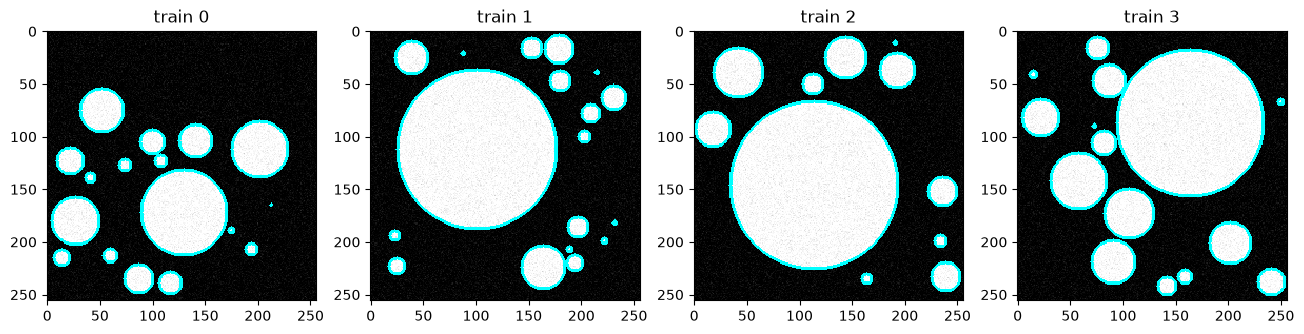

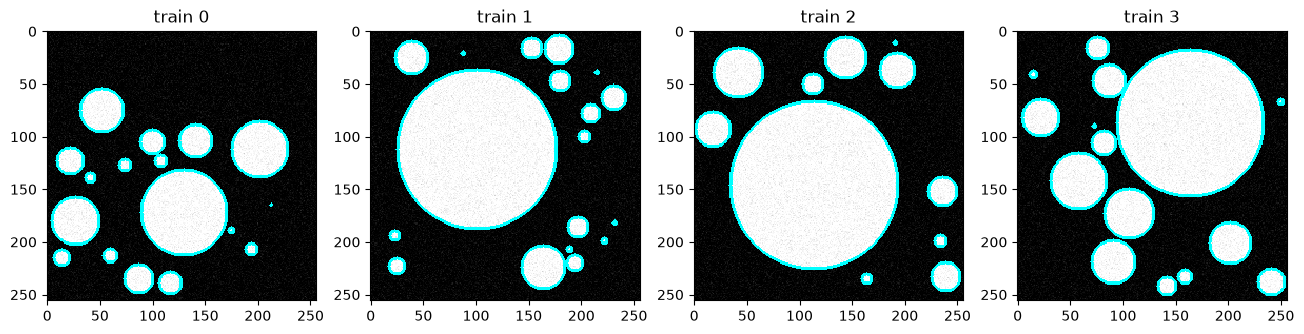

In [8]:
imshow_multi2d([mask_outline_overlay(train_imgs[i], train_lbls[i]) for i in range(4)],
               [f'train {i}' for i in range(4)], 1, 4, width=16, height=4)

## Train the small network

In [9]:
# Retire the worker: ipykernel binds a thread's output to the execution that
# created it, so a reused worker prints the first run only.
runner.close()

def show(ev):
    print(f'{ev.current}/{ev.maximum}  {ev.message}', flush=True)

small_net = runner.run(
    train_stardist2d,
    images=train_images,
    labels=train_truths,
    model_dir=str(WORK / 'models'),
    name='small_net',
    image_axes='YX',
    grid_size_xy=SMALL_GRID,
    unet_n_depth=SMALL_DEPTH,
    train_patch_size=256,
    train_batch_size=1,
    epochs=50,
    steps_per_epoch=10,
    val_size=VAL,
    on_progress=show,
)
print(small_net)

None/None  None
0/16  Reading 16 pairs
1/None  None
2/None  None
3/None  None
4/None  None
5/None  None
6/None  None
7/None  None
8/None  None
9/None  None
10/None  None
11/None  None
12/None  None
13/None  None
14/None  None
15/None  None
16/None  None
0/50  Training small_net: 8 train, 8 val, 50 epochs
1/50  Epoch 1/50 — loss 9.4350, val_loss 9.3750
2/50  Epoch 2/50 — loss 9.6160, val_loss 9.1543
3/50  Epoch 3/50 — loss 9.0649, val_loss 8.9502
4/50  Epoch 4/50 — loss 8.5815, val_loss 8.9186
5/50  Epoch 5/50 — loss 8.6881, val_loss 8.7767
6/50  Epoch 6/50 — loss 8.4370, val_loss 7.7133
7/50  Epoch 7/50 — loss 7.1131, val_loss 6.2712
8/50  Epoch 8/50 — loss 5.7767, val_loss 5.7073
9/50  Epoch 9/50 — loss 5.2224, val_loss 5.3405
10/50  Epoch 10/50 — loss 5.5150, val_loss 5.1937
11/50  Epoch 11/50 — loss 5.2955, val_loss 5.1011
12/50  Epoch 12/50 — loss 5.1498, val_loss 5.0754
13/50  Epoch 13/50 — loss 5.4647, val_loss 5.0808
14/50  Epoch 14/50 — loss 4.8440, val_loss 5.0066
15/50  Epoch

## Train the big network

In [10]:
runner.close()

big_net = runner.run(
    train_stardist2d,
    images=train_images,
    labels=train_truths,
    model_dir=str(WORK / 'models'),
    name='big_net',
    image_axes='YX',
    grid_size_xy=BIG_GRID,
    unet_n_depth=BIG_DEPTH,
    train_patch_size=256,
    train_batch_size=1,
    epochs=50,
    steps_per_epoch=10,
    val_size=VAL,
    on_progress=show,
)
print(big_net)

None/None  None
0/16  Reading 16 pairs
1/None  None
2/None  None
3/None  None
4/None  None
5/None  None
6/None  None
7/None  None
8/None  None
9/None  None
10/None  None
11/None  None
12/None  None
13/None  None
14/None  None
15/None  None
16/None  None
0/50  Training big_net: 8 train, 8 val, 50 epochs
1/50  Epoch 1/50 — loss 9.2856, val_loss 9.2281
2/50  Epoch 2/50 — loss 9.2711, val_loss 8.9602
3/50  Epoch 3/50 — loss 8.6494, val_loss 7.5290
4/50  Epoch 4/50 — loss 7.3671, val_loss 6.5629
5/50  Epoch 5/50 — loss 5.9874, val_loss 5.6753
6/50  Epoch 6/50 — loss 4.7244, val_loss 4.7950
7/50  Epoch 7/50 — loss 5.0522, val_loss 5.5695
8/50  Epoch 8/50 — loss 4.9203, val_loss 4.4927
9/50  Epoch 9/50 — loss 5.0163, val_loss 5.6420
10/50  Epoch 10/50 — loss 5.5780, val_loss 5.1680
11/50  Epoch 11/50 — loss 4.5268, val_loss 3.8158
12/50  Epoch 12/50 — loss 4.0379, val_loss 3.5355
13/50  Epoch 13/50 — loss 3.8450, val_loss 3.7798
14/50  Epoch 14/50 — loss 3.6078, val_loss 3.3823
15/50  Epoch 1

## Predict on the test image

Six circles, sizes it never saw, from 6 px to 140 px.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22470585..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22470585..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22470585..255.0].


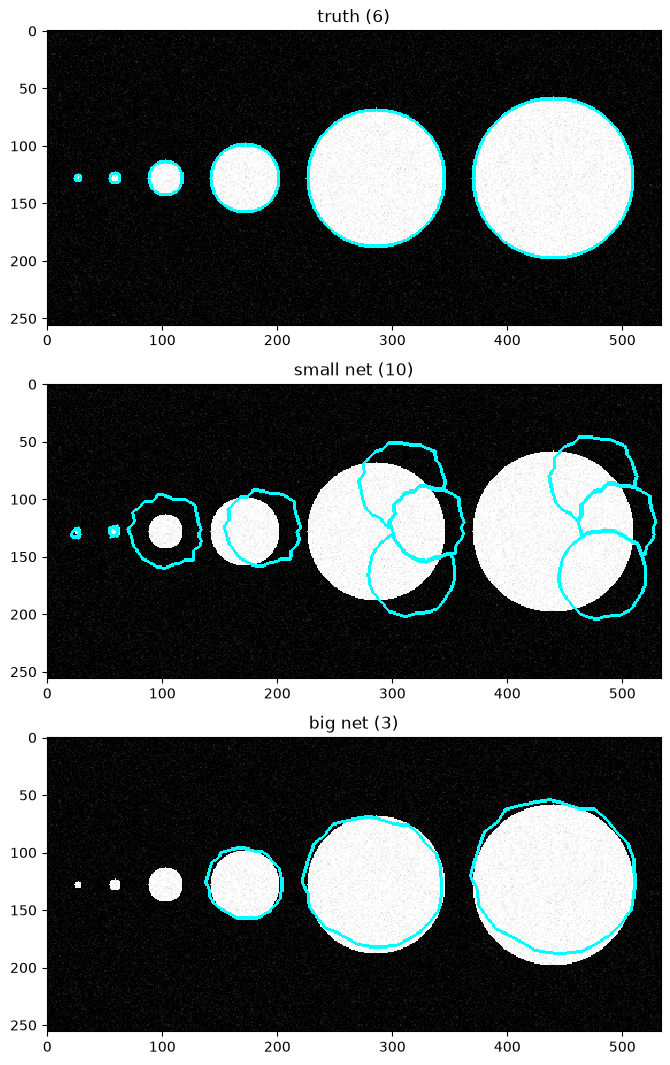

In [11]:
by_small_net = runner.run(stardist2d_custom, image=test_img,
                          model_dir=small_net, normalize=False)
by_big_net = runner.run(stardist2d_custom, image=test_img,
                        model_dir=big_net, normalize=False)

fig = imshow_multi2d(
    [mask_outline_overlay(test_img, test_lbl),
     mask_outline_overlay(test_img, by_small_net),
     mask_outline_overlay(test_img, by_big_net)],
    [f'truth ({test_lbl.max()})',
     f'small net ({by_small_net.max()})',
     f'big net ({by_big_net.max()})'],
    3, 1, width=13, height=13,
)

## Measured size against true size

This is the point. A network that cannot see the edge has to guess the size.

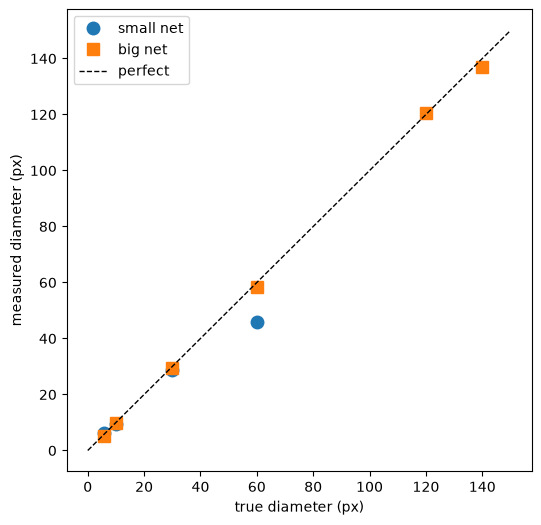

In [16]:
truth_props = {p.label: p for p in regionprops(test_lbl)}

fig, a = plt.subplots(figsize=(6, 6))
for pred, name, style in [(by_small_net, 'small net', 'o'), (by_big_net, 'big net', 's')]:
    found = {p.label: p.equivalent_diameter_area for p in regionprops(pred)}
    xs, ys = [], []
    for label, p in truth_props.items():
        y, x = (int(v) for v in p.centroid)
        hit = pred[y, x]
        if hit:
            xs.append(p.equivalent_diameter_area)
            ys.append(found[hit])
    a.plot(xs, ys, style, label=name, markersize=9)

a.plot([0, 150], [0, 150], 'k--', linewidth=1, label='perfect')
a.set_xlabel('true diameter (px)')
a.set_ylabel('measured diameter (px)')
a.legend()
plt.show()

## What to take away

Match the field to the object. A field smaller than the object cannot see the
edges, so it guesses the size instead of measuring it.